# Process NEP DMS data from Teo et al.

Import Python modules

In [1]:
import os
import pandas as pd
from collections import defaultdict
from Bio import SeqIO
import subprocess

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

In [2]:
import yaml

_config_dir = os.path.dirname(os.path.abspath("../config.yaml"))
with open("../config.yaml") as _f:
    _config = yaml.safe_load(_f)
data_dir = os.path.normpath(os.path.join(_config_dir, _config["data_dir"]))

NEP is encoded by a spliced mRNA from the NS segment. The reference NEP protein is reconstructed by concatenating exon 1 (nt 1-30) and exon 2 (nt 503-838) from the NS reference and translating. The DMS data covers sites 2-113 (112 of the 121 residues); the DMS protein sequence is aligned to the full reference to build a site coordinate mapping.

In [3]:
# Extract the NEP reference protein from the NS segment reference
# NEP CDS: exon 1 (nt 1-30, 0-indexed 0:30) + exon 2 (nt 503-838, 0-indexed 502:838)
ref_fasta = os.path.join(data_dir, 'NS/all/curated_reference.fasta')
ref_seq = SeqIO.read(ref_fasta, 'fasta').seq
nep_cds = ref_seq[0:30] + ref_seq[502:838]
ref_aa_seq = str(nep_cds.translate()).replace('*', '')
print('Reference NEP sequence length:', len(ref_aa_seq))

# Load DMS data; row 0 is a table title so use header=1
raw_dms = pd.read_excel('../data/dms_data/Teo_NEP/mmc2.xlsx', engine='openpyxl', header=1)

# Filter to missense mutations only (exclude nonsense/stop codons)
raw_dms = raw_dms[(raw_dms['mutation_type'] == 'missense') & raw_dms['Position'].notna()].copy()

# Parse wt_aa and mut_aa from NEP_Mutation (e.g. 'D2C' -> wt='D', mut='C')
raw_dms['wt_aa'] = raw_dms['NEP_Mutation'].str[0]
raw_dms['mut_aa'] = raw_dms['NEP_Mutation'].str[-1]

# Rename and select relevant columns
nep_dms_data = (
    raw_dms
    .rename(columns={'Position': 'dms_site', 'average_fit': 'dms_effect'})
    .assign(dms_site=lambda df: df['dms_site'].astype(int))
    [['dms_site', 'wt_aa', 'mut_aa', 'dms_effect']]
)

# Build DMS protein sequence from wildtype AAs at each site
dms_seq_df = (
    nep_dms_data
    .sort_values('dms_site')
    .drop_duplicates('dms_site')
)
dms_aa_seq = ''.join(dms_seq_df['wt_aa'])
print('DMS sequence length:', len(dms_aa_seq))
print('DMS site range:', dms_seq_df['dms_site'].min(), '-', dms_seq_df['dms_site'].max())

# Save sequences to a FASTA file for alignment
output_dir = '../results/dms_data/Teo_NEP/'
if not os.path.isdir(output_dir):
    os.makedirs(output_dir)
unaligned_fasta = os.path.join(output_dir, 'unaligned.fasta')
if not os.path.isfile(unaligned_fasta):
    with open(unaligned_fasta, 'w') as f:
        f.write('>reference\n')
        f.write(ref_aa_seq + '\n')
        f.write('>dms\n')
        f.write(dms_aa_seq + '\n')

# Align the sequences using MUSCLE
aligned_fasta = os.path.join(output_dir, 'aligned.fasta')
if not os.path.isfile(aligned_fasta):
    cmd = ['muscle', '-align', unaligned_fasta, '-output', aligned_fasta]
    result = subprocess.run(cmd, capture_output=True, text=True, check=True)

Reference NEP sequence length: 121


DMS sequence length: 109
DMS site range: 2 - 113


In [4]:
# Read in the aligned sequences
seqs_dict = {}
aligned_records = list(SeqIO.parse(aligned_fasta, 'fasta'))
for record in aligned_records:
    seqs_dict[record.id] = str(record.seq)

aligned_ref_seq = seqs_dict['reference']
aligned_dms_seq = seqs_dict['dms']

# Compute percent identity
n_sites_to_compare = 0
n_identical = 0
for (ref_aa, dms_aa) in zip(aligned_ref_seq, aligned_dms_seq):
    if ref_aa != '-' and dms_aa != '-':
        n_sites_to_compare += 1
        if ref_aa == dms_aa:
            n_identical += 1

print(n_sites_to_compare, n_identical, n_identical / n_sites_to_compare)

# Determine numbering scheme.
# The DMS data may have non-consecutive site numbers (some sites not measured),
# so we use the actual DMS site numbers from dms_seq_df rather than a sequential
# counter. This ensures correct coordinate mapping even when sites are missing.
dms_site_list = dms_seq_df['dms_site'].tolist()  # ordered list of actual DMS sites
numbering_dict = defaultdict(list)
assert len(aligned_ref_seq) == len(aligned_dms_seq)

# Reference: sequential counter starting at 1 (no gaps in reference)
ref_idx = 1
for (alignment_index, aa) in enumerate(aligned_ref_seq, 1):
    if aa != '-':
        numbering_dict['alignment_index'].append(alignment_index)
        numbering_dict['seq_id'].append('tree_reference_site')
        numbering_dict['seq_index'].append(ref_idx)
        numbering_dict['seq_aa'].append(aa)
        ref_idx += 1

# DMS: use actual DMS site numbers (not a sequential counter)
dms_char_idx = 0
for (alignment_index, aa) in enumerate(aligned_dms_seq, 1):
    if aa != '-':
        numbering_dict['alignment_index'].append(alignment_index)
        numbering_dict['seq_id'].append('dms_site')
        numbering_dict['seq_index'].append(dms_site_list[dms_char_idx])
        numbering_dict['seq_aa'].append(aa)
        dms_char_idx += 1

alignment_numbering_df = (
    pd.DataFrame(numbering_dict)
    .pivot(index='alignment_index', columns='seq_id', values='seq_index')
    .reset_index()
    .rename_axis(None, axis=1)
    .dropna()
    [['dms_site', 'tree_reference_site']]
)
alignment_numbering_df['dms_site'] = alignment_numbering_df['dms_site'].astype(int)
alignment_numbering_df['tree_reference_site'] = alignment_numbering_df['tree_reference_site'].astype(int)
alignment_numbering_df.head()

109 104 0.9541284403669725


,dms_site,tree_reference_site
1,2,2
2,3,3
3,4,4
4,5,5
5,6,6


In [5]:
alignment_numbering_df[
    alignment_numbering_df['dms_site'] != alignment_numbering_df['tree_reference_site']
]

,dms_site,tree_reference_site
39,38,40


In [6]:
# Merge DMS data with numbering scheme
nep_dms_data_processed = (
    nep_dms_data
    .merge(alignment_numbering_df, on='dms_site', validate='many_to_one')
)

# Drop the one site where dms_site != tree_reference_site (misalignment of an L in an ambiguous region of the alignment)
nep_dms_data_processed = nep_dms_data_processed[
    nep_dms_data_processed['dms_site'] == nep_dms_data_processed['tree_reference_site']
]

# Save processed DMS data with tree reference site numbering
nep_dms_data_processed = nep_dms_data_processed[['dms_site', 'wt_aa', 'mut_aa', 'tree_reference_site', 'dms_effect']]
nep_dms_data_processed.to_csv(os.path.join(output_dir, 'processed_dms_data.csv'), index=False)
print('Number of mutations with processed data:', len(nep_dms_data_processed))
nep_dms_data_processed.head()

Number of mutations with processed data: 1876


,dms_site,wt_aa,mut_aa,tree_reference_site,dms_effect
0,2,D,C,2,0.120078
1,2,D,S,2,-0.010223
2,2,D,I,2,0.138385
3,2,D,E,2,0.023601
4,2,D,T,2,0.169727


In [7]:
nep_dms_data_processed[
    nep_dms_data_processed['dms_site'].between(37,42)
].drop_duplicates('dms_site')

,dms_site,wt_aa,mut_aa,tree_reference_site,dms_effect
580,37,S,D,37,-0.295161
617,41,Y,W,41,-0.272951
630,42,R,M,42,-0.561962


Make a heatmap of DMS effects

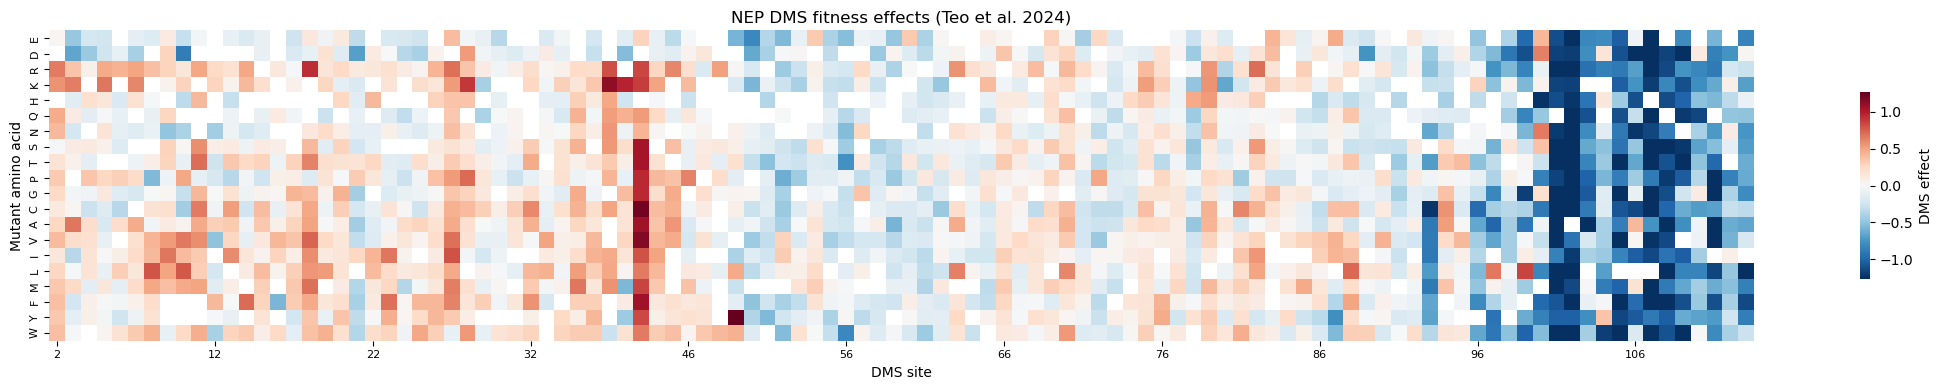

In [8]:
# Amino acid order for y-axis
AA_ORDER = list('EDRKHQNSTPGCAVILMFYW')

# Pivot to wide format: rows=mut_aa, cols=dms_site
heatmap_data = (
    nep_dms_data_processed
    .pivot_table(index='mut_aa', columns='dms_site', values='dms_effect', aggfunc='mean')
    .reindex(AA_ORDER)
)

# Symmetric color scale clipped at 2.5/97.5 percentile to avoid outlier compression
vals = nep_dms_data_processed['dms_effect']
vlim = max(abs(vals.quantile(0.025)), abs(vals.quantile(0.975)))

fig, ax = plt.subplots(figsize=(22, 4))
sns.heatmap(
    heatmap_data, ax=ax,
    cmap='RdBu_r', center=0, vmin=-vlim, vmax=vlim,
    xticklabels=True, yticklabels=True,
    cbar_kws={'label': 'DMS effect', 'shrink': 0.6},
    linewidths=0,
)

# Show every 10th site on x-axis to avoid crowding
n_sites = len(heatmap_data.columns)
xtick_positions = range(0, n_sites, 10)
ax.set_xticks([p + 0.5 for p in xtick_positions])
ax.set_xticklabels([heatmap_data.columns[p] for p in xtick_positions], rotation=0, fontsize=8)

ax.set(xlabel='DMS site', ylabel='Mutant amino acid', title='NEP DMS fitness effects (Teo et al. 2024)')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()